<a href="https://colab.research.google.com/github/ExTc-aShiSh/Introduction-to-AI/blob/main/Routing_by_DFS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Depth First Search (DFS) is an algorithm for traversing or searching tree or graph data structures. The algorithm starts at the root (or an arbitrary node) and explores as far as possible along each branch before backtracking.

Here's a Python implementation using an adjacency list to represent the graph.

Route found: Shimla -> Mandi -> Hamirpur -> Kangra -> Dharamshala


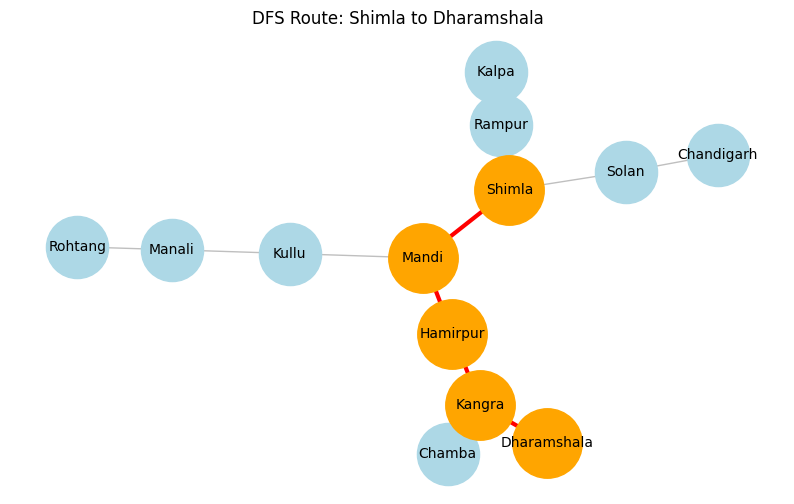

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

def find_route_dfs(graph, start, goal, visited=None, path=None):
    if visited is None:
        visited = set()
    if path is None:
        path = []

    visited.add(start)
    path.append(start)

    if start == goal:
        return path

    for neighbor in graph.get(start, []):
        if neighbor not in visited:
            result = find_route_dfs(graph, neighbor, goal, visited, path.copy())
            if result:
                return result
    return None

# 1. Define the Himachal Pradesh City Connectivity Graph
hp_roads = {
    'Shimla': ['Solan', 'Mandi', 'Rampur'],
    'Solan': ['Shimla', 'Chandigarh'],
    'Mandi': ['Shimla', 'Kullu', 'Hamirpur'],
    'Kullu': ['Mandi', 'Manali'],
    'Manali': ['Kullu', 'Rohtang'],
    'Hamirpur': ['Mandi', 'Kangra'],
    'Kangra': ['Hamirpur', 'Dharamshala', 'Chamba'],
    'Dharamshala': ['Kangra'],
    'Chamba': ['Kangra'],
    'Rampur': ['Shimla', 'Kalpa'],
    'Kalpa': ['Rampur']
}

# 2. Find the route using DFS
start_city = 'Shimla'
end_city = 'Dharamshala'
route = find_route_dfs(hp_roads, start_city, end_city)

# 3. Print the result
if route:
    print(f"Route found: {' -> '.join(route)}")

    # 4. Visualize the graph and the path
    G = nx.Graph()
    for city, neighbors in hp_roads.items():
        for neighbor in neighbors:
            G.add_edge(city, neighbor)

    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=42)
    route_edges = [(route[i], route[i+1]) for i in range(len(route)-1)]

    # Draw base graph
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')
    nx.draw_networkx_labels(G, pos, font_size=10)
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)

    # Highlight route
    nx.draw_networkx_nodes(G, pos, nodelist=route, node_color='orange', node_size=2500)
    nx.draw_networkx_edges(G, pos, edgelist=route_edges, edge_color='red', width=3)

    plt.title(f"DFS Route: {start_city} to {end_city}")
    plt.axis('off')
    plt.show()
else:
    print(f"No route found between {start_city} and {end_city}.")